# The 60/40 Portfolio — a quantitative teardown 🔬
### Real total-return tapes · excess-of-cash Sharpe · HAC + block-bootstrap on the Sharpe difference · the bond-bull read

![Signal: Real](https://img.shields.io/badge/Signal-Real-2ea44f?style=flat-square)
![Tradability: Investable](https://img.shields.io/badge/Tradability-Investable-2ea44f?style=flat-square)
![Bonds cushion every crash?: Not supported](https://img.shields.io/badge/Bonds_cushion_every_crash%3F-Not_supported-8b949e?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb) — *same seven beats, every claim now carrying its standard error.* We separate the three things 60/40 sells — **risk reduction** (real), a **risk-adjusted edge** (real, and it survives inference), and an **always-on crash cushion** (not supported) — and ask how much of the edge is the disinflation-era **bond bull**.

> ⚠️ **Not investment advice.** SPY/IEF/TLT/SHY daily, total-return adjusted (`balancing_act.data`, yfinance `auto_adjust=True`); Sharpe is excess-of-cash (SHY); annual rebalance, 2 bps/rebalance. Treasury ETFs bound the window at 2002-07-30. Sources in [`docs/references.md`](../docs/references.md), reproducible run in [`docs/results.md`](../docs/results.md).
>
> 💡 **The `💡 In plain words` notes** translate each result back into intuition.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # study root (balancing_act/)
sys.path.insert(0, os.path.abspath("../../.."))    # repo root (quantlab/)
%matplotlib inline
import matplotlib.pyplot as plt
plt.rcParams["figure.figsize"] = (10, 5.5)
import numpy as np, pandas as pd
pd.set_option("display.float_format", lambda v: f"{v:,.3f}")
from balancing_act import data, strategy

AS_OF = "2026-06-12"
prices = data.load_real(("SPY", "IEF", "TLT", "SHY")).loc[:AS_OF]
rets = strategy.to_returns(prices)
rf = rets["SHY"]
blend_ret = strategy.rebalanced_blend(rets, {"SPY": 0.60, "IEF": 0.40}, "annual", cost_bps=2.0)
blend = strategy.stats(blend_ret, rf=rf)
spy = strategy.stats(strategy.single_asset(rets, "SPY"), rf=rf)
print(f"panel: {len(prices):,} rows  {prices.index[0].date()} -> {prices.index[-1].date()}  fingerprint={data.fingerprint(prices)}")
print(f"60/40  Sharpe(xs) {blend['sharpe']:.3f}  vol {blend['vol']*100:.1f}%  maxDD {blend['max_dd']*100:.1f}%  CAGR {blend['cagr']*100:.2f}%")
print(f"SPY    Sharpe(xs) {spy['sharpe']:.3f}  vol {spy['vol']*100:.1f}%  maxDD {spy['max_dd']*100:.1f}%  CAGR {spy['cagr']*100:.2f}%")


panel: 6,006 rows  2002-07-30 -> 2026-06-11  fingerprint=75b675e02dc5
60/40  Sharpe(xs) 0.655  vol 10.2%  maxDD -29.8%  CAGR 8.63%
SPY    Sharpe(xs) 0.541  vol 18.8%  maxDD -55.2%  CAGR 11.20%


## Verdict, up front

| Axis | Stamp | Why |
|---|---|---|
| **Signal** | `REAL` | Excess-of-cash Sharpe **0.655** vs **0.541** (edge **+0.115**); HAC *t* on the daily return difference **-2.28** (\|t\| > 2), block-bootstrap 95% CI **[+0.022, +0.207]** excludes 0. |
| **Tradability** | `INVESTABLE` | Two cheap ETFs, annual rebalance — *with caveats*: **2.6 pts/yr** of CAGR given up, and much of the Sharpe edge is the bond bull (beta). |
| **Bonds cushion every crash?** | `NOT SUPPORTED` | 6/8 crashes cushioned; **2022** failed (60/40 -17.0%). |

> 💡 **In plain words:** 60/40 is a *real, investable risk reducer* whose headline cushion story has a regime-shaped hole in it.

## 1 · The claim, steelmanned

- **H₁ (risk):** the fixed 60/40 lowers volatility and drawdown vs 100% stocks.
- **H₂ (risk-adjusted edge):** it improves the *excess-of-cash Sharpe*, and the improvement survives autocorrelation-robust inference.
- **H₃ (the cushion law):** bonds rally in *every* equity crash.

H₁ and H₂ hold; H₃ does not — and a chunk of H₂ is bond-bull beta, not a structural law.

## 2 · So what? — what rides on each answer

If H₂ is a free structural law, 60/40 is the right default forever. If most of it is the bond bull, the forward case is much weaker — the same caveat the desk drew for [All-Weather](../../68-all-weather/).

## 3 · How we'd know — the protocol

Excess-of-cash Sharpe (SHY proxy) · HAC *t* on the daily return difference · circular block-bootstrap CI on the Sharpe *difference* · rolling stock/bond correlation across regimes · the cushion tested on every >10% drawdown and on 2022.

## 4 · The teardown

Headline stats, excess-of-cash Sharpe, net of 2 bps/rebalance:

In [2]:
blend_tlt = strategy.stats(strategy.rebalanced_blend(rets, {'SPY':0.6,'TLT':0.4},'annual',2.0), rf=rf)
tbl = pd.DataFrame({
  'CAGR %':      [blend['cagr']*100, blend_tlt['cagr']*100, spy['cagr']*100],
  'Vol %':       [blend['vol']*100, blend_tlt['vol']*100, spy['vol']*100],
  'Sharpe (xs)': [blend['sharpe'], blend_tlt['sharpe'], spy['sharpe']],
  'MaxDD %':     [blend['max_dd']*100, blend_tlt['max_dd']*100, spy['max_dd']*100],
}, index=['60/40 (SPY/IEF)', '60/40 (SPY/TLT)', '100% stocks (SPY)'])
tbl.round(2)

,CAGR %,Vol %,Sharpe (xs),MaxDD %
60/40 (SPY/IEF),8.630,10.240,0.660,-29.770
60/40 (SPY/TLT),8.960,10.470,0.680,-27.630
100% stocks (SPY),11.200,18.830,0.540,-55.190


**Is the Sharpe edge real?** HAC *t* on the daily excess-return difference (60/40 − SPY), then a circular block-bootstrap CI on the Sharpe *difference*.

In [3]:
ex_blend = (blend_ret - rf).reindex(blend_ret.index).fillna(0.0)
ex_spy = (rets['SPY'] - rf)
t = strategy.hac_tstat((ex_blend - ex_spy).to_numpy())
boot = strategy.bootstrap_sharpe_diff(blend_ret, rets['SPY'], rf=rf, block=21, n_boot=2000, seed=97)
print(f'Sharpe edge (60/40 - SPY, xs) = {blend["sharpe"]-spy["sharpe"]:+.3f}')
print(f'HAC t on daily (60/40 - SPY) xs-return diff = {t:+.2f}')
print(f'bootstrap Sharpe diff = {boot["point"]:+.3f}  95% CI [{boot["ci95"][0]:+.3f}, {boot["ci95"][1]:+.3f}]  60/40 wins {boot["frac_a_wins"]*100:.0f}%')

Sharpe edge (60/40 - SPY, xs) = +0.115
HAC t on daily (60/40 - SPY) xs-return diff = -2.28
bootstrap Sharpe diff = +0.115  95% CI [+0.022, +0.207]  60/40 wins 99%


> 💡 **In plain words:** the blend earns a touch less *per day* (so the mean difference is negative, and the HAC *t* is **−2.28**), but it does so with far less variance — so on a risk-adjusted basis the bootstrap says the improvement is real (whole CI above zero).

**The cushion, every >10% equity drawdown** — did the bond leg rise during it?

In [4]:
eps = strategy.equity_drawdowns(rets[['SPY','IEF','TLT']], 'SPY', thresh=-0.10)
rows = [{'peak':e['peak'].date(),'trough':e['trough'].date(),'SPY %':e['stock_loss']*100,'IEF %':e['others']['IEF']*100,'TLT %':e['others']['TLT']*100} for e in eps]
dd = pd.DataFrame(rows)
cushioned = (dd['IEF %']>0).sum()
print(f'bonds (IEF) rose in {cushioned}/{len(dd)} of the >10% equity crashes')
dd.round(1)

bonds (IEF) rose in 6/8 of the >10% equity crashes


,peak,trough,SPY %,IEF %,TLT %
0,2002-08-22,2002-10-09,-18.900,5.400,6.800
1,2007-10-09,2009-03-09,-55.200,20.200,25.100
2,2015-07-20,2016-02-11,-13.000,7.400,14.800
3,2018-01-26,2018-02-08,-10.100,-1.200,-3.800
4,2018-09-20,2018-12-24,-19.300,3.400,4.500
5,2020-02-19,2020-03-23,-33.700,6.400,14.200
6,2022-01-03,2022-10-12,-24.500,-15.400,-29.300
7,2025-02-19,2025-04-08,-18.800,2.700,0.800


> 💡 **In plain words:** in 6 of 8 crashes Treasuries did their job. The exception is the last row — **2022** — where IEF fell ~15% and TLT ~29% *into* the equity selloff.

**Rolling stock/bond correlation** — the cushion is whatever this line is doing:

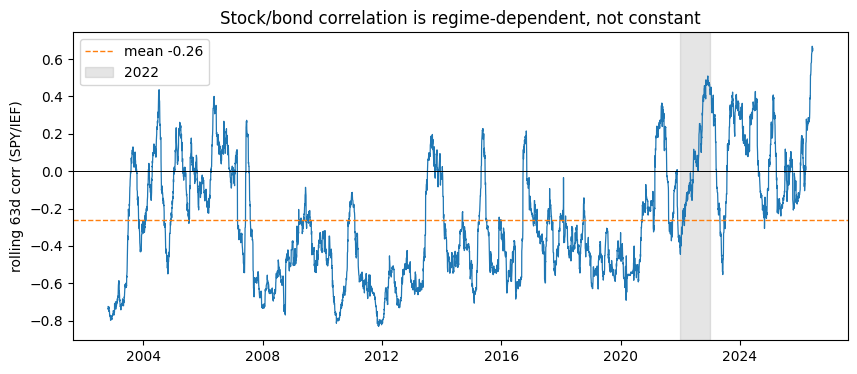

positive on 23% of days; range [-0.83, +0.67]


In [5]:
rc = strategy.rolling_correlation(rets, 'SPY', 'IEF', window=63).dropna()
fig, ax = plt.subplots(figsize=(10,4))
ax.plot(rc.index, rc.values, lw=.9); ax.axhline(0, color='k', lw=.7)
ax.axhline(rc.mean(), color='C1', ls='--', lw=1, label=f'mean {rc.mean():+.2f}')
ax.axvspan(pd.Timestamp('2022-01-01'), pd.Timestamp('2022-12-31'), color='grey', alpha=.2, label='2022')
ax.set_ylabel('rolling 63d corr (SPY/IEF)'); ax.legend(); ax.set_title('Stock/bond correlation is regime-dependent, not constant')
plt.show()
print(f'positive on {(rc>0).mean()*100:.0f}% of days; range [{rc.min():+.2f}, {rc.max():+.2f}]')

## 5 · The verdict

Signal `REAL` (Sharpe +0.115, HAC *t* -2.28, bootstrap CI [+0.022, +0.207] excludes 0); Tradability `INVESTABLE` with caveats (−2.6 pts/yr CAGR, much of the edge is bond-bull beta); Bonds-cushion-every-crash? `NOT SUPPORTED` (6/8, 2022 failed).

## 6 · Could you trade it?

Capacity is a non-issue (SPY + IEF). The honest reservations are economic: (1) it delivers **less return for less risk** — a deliberate de-risking, not alpha; (2) the realised Sharpe edge leaned on a **40-year bond bull** (a yield decline you were paid for, i.e. beta) that 2022 reminded everyone is not guaranteed; (3) the diversification can **switch off** in a rate-shock regime. As a default core: yes. As a free structural law: no.

## 7 · Going further

- Re-estimate the Sharpe edge on a **post-2010** sub-sample with a block-bootstrap on the *difference* — how much shrinks once the GFC bond rally is out of sample?
- Strip the bond bull: re-price IEF assuming flat forward yields and recompute.
- Compare to the *volatility*-weighted version in [Study 68](../../68-all-weather/) — fixed 60/40 vs risk parity on the same tape.